# [Práctica 5] Fundamentos de Ciencia de Datos
Alejandra Fernández (afernandezm@inf.udec.cl)

# Contenidos
-  **Codificar variables categoricas**
    - A mano
    - Automatico
- **Clasificacion**
  - Concepto
  - Metricas
  - Modelos
      - SVM
      - Árbol de decisión
      - Random Forest
- **Validación cruzada con un clasificador**
- **Ejercicio**


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

#Codificar variables categoricas

Hasta el momento, hemos visto com trabajar con datos númericos, es decir, con variables cuantitativas. Para que los modelos puedan trabajar con variables categoricas, debemos hacer una transformación para poder pasarlas a números.

In [29]:
#Creemos un dataset de prueba
datos = {
    "Kg" : [2.5, 1.8, 3.2, 1.1, 0.6, 5.0, 4.5, 6.7, 4.3, 2.8],
    "Fruta" : ["Plátano", "Manzana Verde", "Manzana Roja", "Mandarina", "Manzana Roja", "Pera", "Plátano", "Pera", "Manzana Roja", "Manzana Verde"],
    "Importado" : ["No", "Si", "Si", "No", "No", "Si", "Si", "No", "No", "No"],
    "Precio" : [2890, 2500, 3450, 1050, 700, 5400, 5200, 6750, 3100, 1750]
}

tabla = pd.DataFrame(datos)

## A mano

Podemos realizar una transformación "a mano" utilizando un diccionario y la función *replace*

In [30]:
diccionario = {
    "Plátano" : 1,
    "Manzana Verde" : 2 ,
    "Manzana Roja": 3,
    "Mandarina" : 4,
    "Pera": 5,
}
tabla2 = tabla.replace(diccionario)
tabla2["Importado"].replace({"Si" : 1,"No" : 0},  inplace=True)
tabla2

/tmp/ipykernel_3071/1478545055.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tabla2 = tabla.replace(diccionario)
/tmp/ipykernel_3071/1478545055.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tabla2["Importado"].replace({"Si" : 1,"No" : 0},  inplace=True)
/tmp/ipykernel_3071/1478545055.py:

,Kg,Fruta,Importado,Precio
0,2.5,1,0,2890
1,1.8,2,1,2500
2,3.2,3,1,3450
3,1.1,4,0,1050
4,0.6,3,0,700
5,5.0,5,1,5400
6,4.5,1,1,5200
7,6.7,5,0,6750
8,4.3,3,0,3100
9,2.8,2,0,1750


##Automatico

### Get_dummies
La función get_dummies crea una columna booleana para cada valor categorico. (usa el método de one-hot encoding)

One-hot Encoding es la manera de representar variables categoricas como un vector de 0s y 1s. Solo hay un valor 1, que representa la categoria del elemento (en base a su posición).


In [31]:
tabla1 = pd.get_dummies(tabla)
tabla1

,Kg,Precio,Fruta_Mandarina,Fruta_Manzana Roja,Fruta_Manzana Verde,Fruta_Pera,Fruta_Plátano,Importado_No,Importado_Si
0,2.5,2890,False,False,False,False,True,True,False
1,1.8,2500,False,False,True,False,False,False,True
2,3.2,3450,False,True,False,False,False,False,True
3,1.1,1050,True,False,False,False,False,True,False
4,0.6,700,False,True,False,False,False,True,False
5,5.0,5400,False,False,False,True,False,False,True
6,4.5,5200,False,False,False,False,True,False,True
7,6.7,6750,False,False,False,True,False,True,False
8,4.3,3100,False,True,False,False,False,True,False
9,2.8,1750,False,False,True,False,False,True,False


¿Que pasa si hay un NaN?

In [32]:
fila_nueva = pd.DataFrame([{"Kg" : 0.9, "Fruta" : float("nan"), "Importado" : "No", "Precio" : 2890}])
tabla3 = pd.concat([tabla, fila_nueva], ignore_index=True)

tabla3

,Kg,Fruta,Importado,Precio
0,2.5,Plátano,No,2890
1,1.8,Manzana Verde,Si,2500
2,3.2,Manzana Roja,Si,3450
3,1.1,Mandarina,No,1050
4,0.6,Manzana Roja,No,700
5,5.0,Pera,Si,5400
6,4.5,Plátano,Si,5200
7,6.7,Pera,No,6750
8,4.3,Manzana Roja,No,3100
9,2.8,Manzana Verde,No,1750


In [33]:
#Simplemente un nan tendrá todas las columnas con valor 0
pd.get_dummies(tabla3)

,Kg,Precio,Fruta_Mandarina,Fruta_Manzana Roja,Fruta_Manzana Verde,Fruta_Pera,Fruta_Plátano,Importado_No,Importado_Si
0,2.5,2890,False,False,False,False,True,True,False
1,1.8,2500,False,False,True,False,False,False,True
2,3.2,3450,False,True,False,False,False,False,True
3,1.1,1050,True,False,False,False,False,True,False
4,0.6,700,False,True,False,False,False,True,False
5,5.0,5400,False,False,False,True,False,False,True
6,4.5,5200,False,False,False,False,True,False,True
7,6.7,6750,False,False,False,True,False,True,False
8,4.3,3100,False,True,False,False,False,True,False
9,2.8,1750,False,False,True,False,False,True,False


Pdemos forzar a que se cree una columna booleana para los nan

In [34]:
pd.get_dummies(tabla3, dummy_na=True)

,Kg,Precio,Fruta_Mandarina,Fruta_Manzana Roja,Fruta_Manzana Verde,Fruta_Pera,Fruta_Plátano,Fruta_nan,Importado_No,Importado_Si,Importado_nan
0,2.5,2890,False,False,False,False,True,False,True,False,False
1,1.8,2500,False,False,True,False,False,False,False,True,False
2,3.2,3450,False,True,False,False,False,False,False,True,False
3,1.1,1050,True,False,False,False,False,False,True,False,False
4,0.6,700,False,True,False,False,False,False,True,False,False
5,5.0,5400,False,False,False,True,False,False,False,True,False
6,4.5,5200,False,False,False,False,True,False,False,True,False
7,6.7,6750,False,False,False,True,False,False,True,False,False
8,4.3,3100,False,True,False,False,False,False,True,False,False
9,2.8,1750,False,False,True,False,False,False,True,False,False


### LabelEncoder

Transforma los valores desde 0 hasta el número de clases.

Se aconseja utilizar solo en la variable objetivo ($Y$)

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
tabla_aux = tabla.copy()
tabla_aux['Fruta']= le.fit_transform(tabla_aux['Fruta'])
tabla_aux

,Kg,Fruta,Importado,Precio
0,2.5,4,No,2890
1,1.8,2,Si,2500
2,3.2,1,Si,3450
3,1.1,0,No,1050
4,0.6,1,No,700
5,5.0,3,Si,5400
6,4.5,4,Si,5200
7,6.7,3,No,6750
8,4.3,1,No,3100
9,2.8,2,No,1750


Puedo obtener el valor original

In [36]:
le.inverse_transform([1])

array(['Manzana Roja'], dtype=object)

In [37]:
codigos = np.array([tabla_aux.Fruta.unique(), le.inverse_transform(tabla_aux.Fruta.unique())]).T
pd.DataFrame(codigos).sort_values(0)

,0,1
3,0,Mandarina
2,1,Manzana Roja
1,2,Manzana Verde
4,3,Pera
0,4,Plátano


#Clasificación

##Concepto

El problema de clasificacion consistira en **etiquetar automaticamente** muestras **no observadas** utilizando alguno de estos dos enfoques:
- <u>Modelos Generativos</u>: Determinar la densidad condicionada a cada clase $p(\boldsymbol{x}|C_k)$, donde $C_k$ es la clase y $P(C_k)$ es la probabilidad a priori. Este enfoque utiliza **la probabilidad conjunta** (implicita o explicitamente)
- <u>Modelos Discriminativos</u>:
    - Inferir directamente **el posterior** de la clase $p(C_k|\boldsymbol{x})$ y luego asignar nuevas observaciones a la clase mas apropiada.
    - Aprender una funcion $f(\boldsymbol{x})$, llamada **funcion discriminativa**. la cual mapea las muestras $\boldsymbol{x} \rightarrow C_k$, con $k=0...,K-1$ al espacio de $K$ estiquetas. En este enfoque no utilizamos la probabilidad.  

##Métricas

###¿Que significa TP, TN, FP, FN ?

Pensemos en un modelo que solo nos diga si una imagen es una "Guitarra" o no.

Si yo tengo una entrada X y la etiqueta es "Guitarra" puede suceder:
* El modelo predijo "Guitarra"  -> **True Positive**
* El modelo predijo que no era "Guitarra" -> **False Negative**

Si yo tengo una entrada X' y su etiqueta no es "Guitarra" puede suceder:
* El modelo predijo "Guitarra" -> **False Positive**
* El modelo predijo que no era "Guitarra" -> **True Negative**

En clasificacion solemos utilizar **Accuracy** (exactitud) para evaluar el clasificador. Esta metrica consiste en:

\begin{eqnarray}
\text{Accuracy} = \frac{\text{True Postive} + \textrm{True Negative}}{\text{True Positive} + \text{False Positive} + \text{True Negative} + \text{False Negative}}
\end{eqnarray}

Sin embargo, esta metrica es invariante a conjuntos de datos desbalanceados, para ello podemos utilizar **Balanced Accuracy** (exactitud balanceada):

\begin{eqnarray}
\text{Balanced Accuracy} = \frac{1}{K}\sum_k^K \frac{\text{Casos Positivos}_k}{\text{Casos Totales}_k}
\end{eqnarray}
donde $K$ es el numero de clases

Otra metrica ampliamente utilizada en Clasificacion es el **F1 score** el cual es una media harmonica entre **Precision** y **Recall**
\begin{eqnarray}
    \textrm{F1} & = &\frac{1}{K} \sum_{k=0}^{K-1} 2 \times \frac{\textrm{Precision}_k \times \textrm{Recall}_k}{\textrm{Precision}_k + \textrm{Recall}_k}
    \nonumber
\end{eqnarray}
donde,
\begin{eqnarray}
    \textrm{Recall}_k & = &  \frac{\textrm{True Positives}_k}{\textrm{True Positives}_k + \textrm{False Negatives}_k}
    \nonumber\\
    \textrm{Precision}_k & = &   \frac{\textrm{True Positives}_k}{\textrm{True Positives}_k + \textrm{False Positives}_k}.
    \nonumber
\end{eqnarray}

Intuitivamente, el **Precision** determina cuantos de nuestras predicciones son correctas  mientras que el **Recall** indica el numero de etiquetas verdaderas que fueron correctamente identificadas por el clasificador.


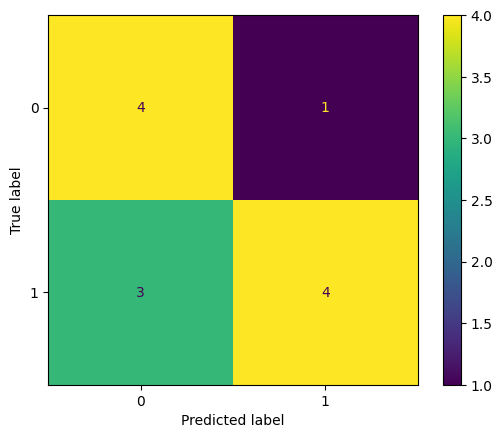

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
#Tengo 7 imagenes con etiqueta "Guitarra", de las cuales dije que 4 eran "Guitarra" y el resto no
#Tengo 5 imagenes que no tienen la etiqueta "Guitarra", de las cuales dije que solo 1 era "Guitarra".
test = [1,1,1,1,1,1,1,0,0,0,0,0]
prediccion = [1,1,1,1,0,0,0,0,0,0,0,1]
ConfusionMatrixDisplay.from_predictions(test, prediccion)

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [40]:
accuracy_score(test, prediccion)

0.6666666666666666

In [41]:
#ACURRACY A MANO
tp = 4
tn = 4
fp = 1
fn = 3
print((tp+tn)/(tp+tn+fp+fn))

0.6666666666666666


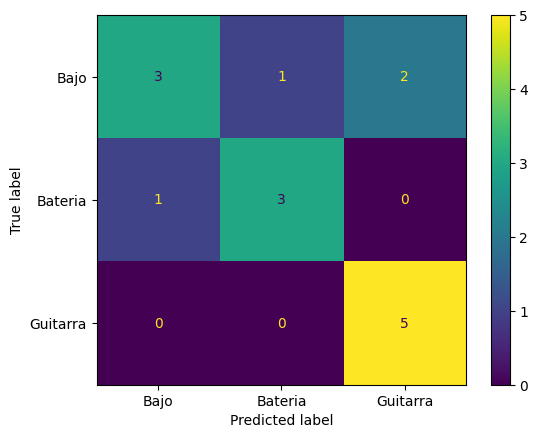

In [42]:
# ¿Y si tuvieramos 3 clases?
# Clases: "Guitarra" (0), "Bajo" (1), "Bateria" (2)
test_string = ["Bateria","Bateria","Bateria","Bateria","Bajo","Bajo","Bajo","Bajo","Bajo","Bajo","Guitarra","Guitarra","Guitarra","Guitarra","Guitarra"]
pred_string = ["Bajo","Bateria","Bateria","Bateria","Bajo","Bajo","Bateria","Guitarra","Guitarra","Bajo","Guitarra","Guitarra","Guitarra","Guitarra","Guitarra"]
ConfusionMatrixDisplay.from_predictions(test_string, pred_string)

In [43]:
from sklearn.metrics import classification_report

print(classification_report(test_string,pred_string))

              precision    recall  f1-score   support

        Bajo       0.75      0.50      0.60         6
     Bateria       0.75      0.75      0.75         4
    Guitarra       0.71      1.00      0.83         5

    accuracy                           0.73        15
   macro avg       0.74      0.75      0.73        15
weighted avg       0.74      0.73      0.72        15



In [44]:
# RECALL A MANO

# Guitarra
tp_gui = 5
fp_gui = 2
fn_gui = 0
tn_gui = 8

# Bajo
tp_baj = 3
fp_baj = 1
fn_baj = 3
tn_baj = 8

# Bateria
tp_bat = 3
fp_bat = 1
fn_bat = 1
tn_bat = 10


print("*"*50, "Recall:", "*"*50)

print(f"recall_guitarra: {tp_gui / (tp_gui + fn_gui)}")
print(f"recall_bajo: {tp_baj / (tp_baj + fn_baj)}")
print(f"recall_bateria: {tp_bat / (tp_bat + fn_bat)}")

rec_mean = (
    tp_gui / (tp_gui + fn_gui) +
    tp_baj / (tp_baj + fn_baj) +
    tp_bat / (tp_bat + fn_bat)
) / 3

print(f"recall promedio (a mano): {rec_mean:.3f}")

************************************************** Recall: **************************************************
recall_guitarra: 1.0
recall_bajo: 0.5
recall_bateria: 0.75
recall promedio (a mano): 0.750


##Modelos

Vamos a ocupar el dataset de juguete de iris.

En este dataset tenemos los datos:
- longitud del sépalo
- ancho del sépalo
- longitud del pétalo
- ancho del pétalo

Cada fila pertenece a una planta (iris) cuya clase puede ser:
- Setosa
- Versicolour
- Virginica


In [45]:
from sklearn.datasets import load_iris
iris = load_iris()

In [46]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [47]:
iris_df = pd.DataFrame(data= iris.data, columns= iris.feature_names)
iris_df["species"] = pd.DataFrame(data= iris.target, columns= ['species'])
iris_df.tail(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
140,6.7,3.1,5.6,2.4,2
141,6.9,3.1,5.1,2.3,2
142,5.8,2.7,5.1,1.9,2
143,6.8,3.2,5.9,2.3,2
144,6.7,3.3,5.7,2.5,2
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [48]:
tipo = pd.DataFrame(data= iris.target_names, columns= ['species'])
tipo

,species
0,setosa
1,versicolor
2,virginica


In [49]:
print("Dimensiones del dataset:", iris_df.shape)
print("\nTipos de datos:")
print(iris_df.dtypes)
print("\nValores nulos:")
print(iris_df.isnull().sum())

Dimensiones del dataset: (150, 5)

Tipos de datos:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

Valores nulos:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [50]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [51]:
iris_df["tipo"] = iris_df["species"].replace(tipo.to_dict()["species"])

Text(0.5, 1.0, 'Datos por clase')

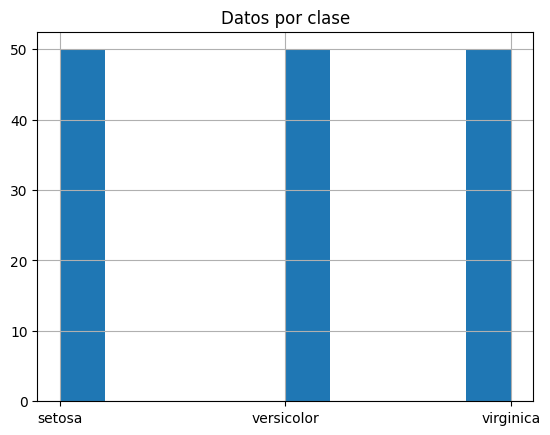

In [52]:
iris_df.tipo.hist()
plt.title("Datos por clase")

<Axes: xlabel='tipo', ylabel='count'>

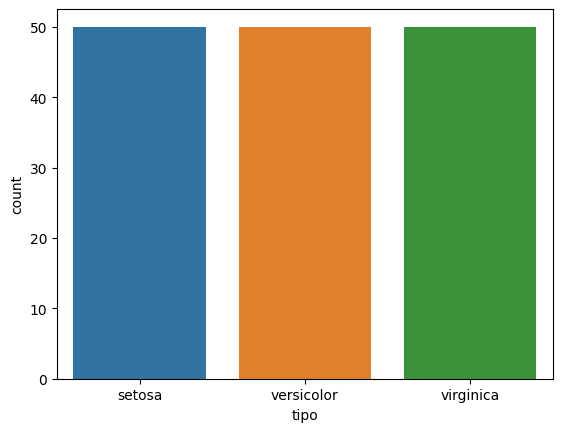

In [53]:
import seaborn as sns
sns.countplot(data=iris_df, x="tipo", hue="tipo")

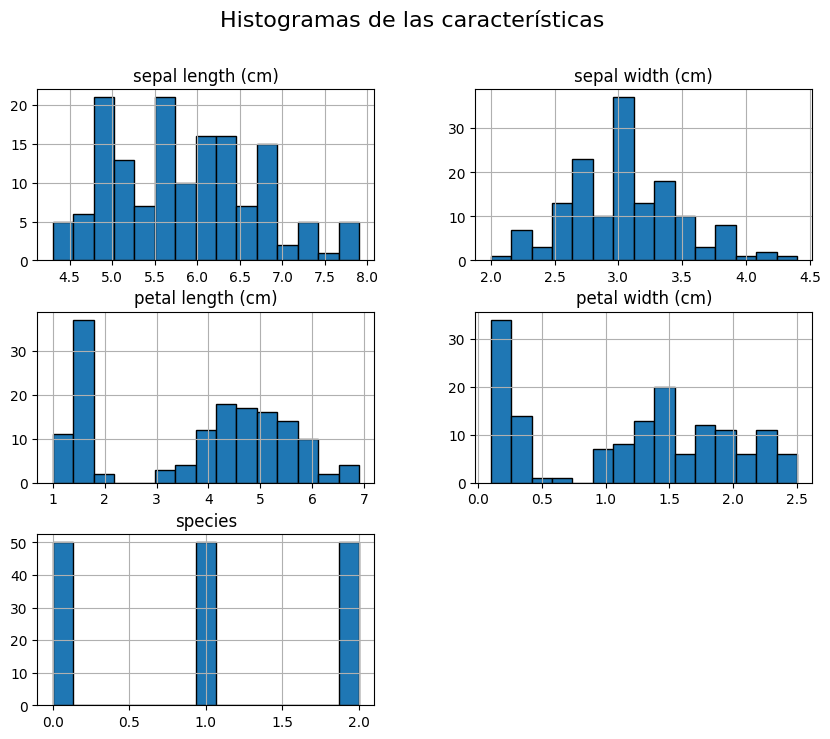

In [54]:
iris_df.hist(bins=15, edgecolor="black", figsize=(10,8))
plt.suptitle("Histogramas de las características", fontsize=16)
plt.show()

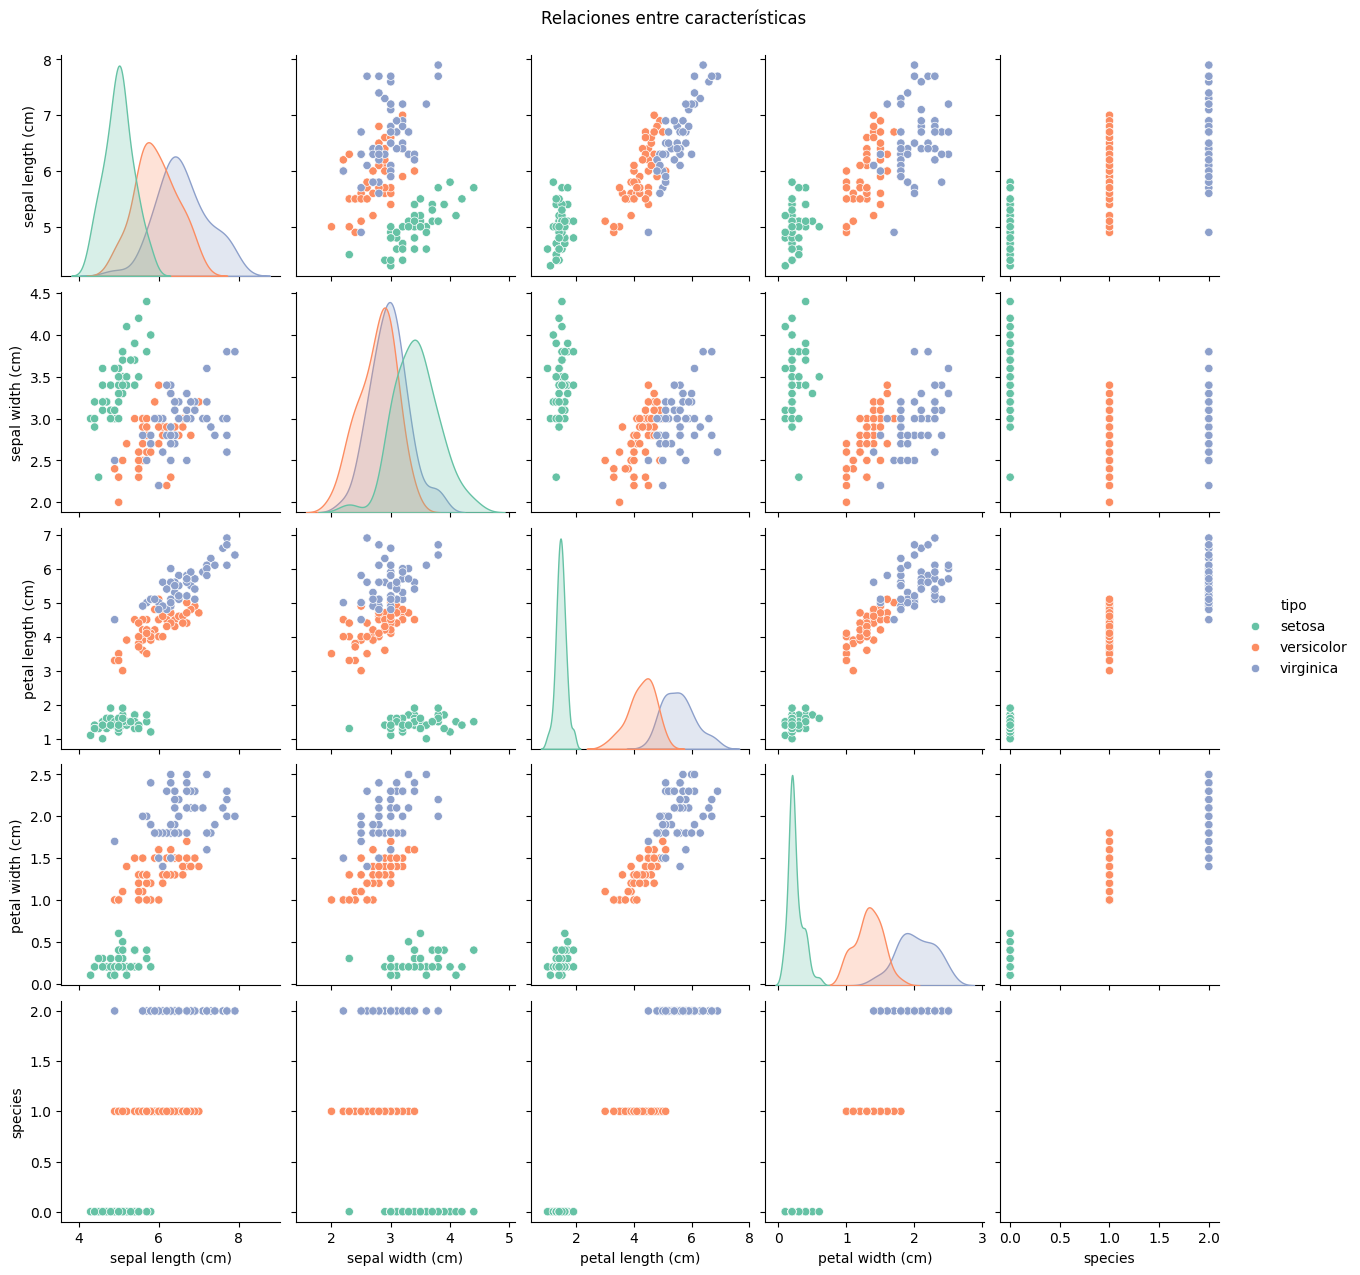

In [55]:
sns.pairplot(iris_df, hue="tipo", palette="Set2")
plt.suptitle("Relaciones entre características", y=1.02)
plt.show()

In [56]:
X = iris_df[['sepal length (cm)', 'sepal width (cm)']].values
y = iris_df.species
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=10, shuffle = True)

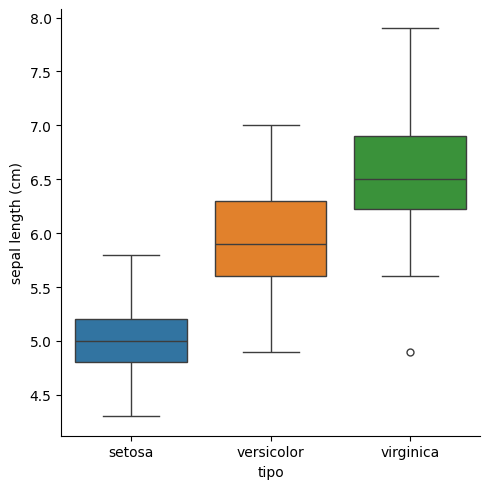

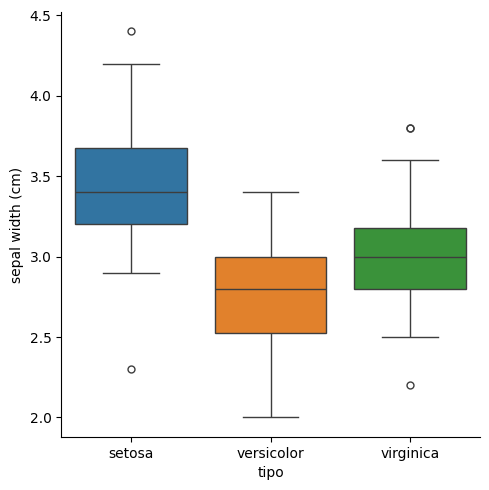

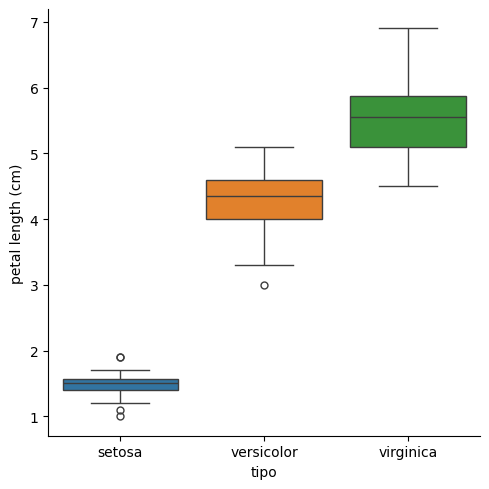

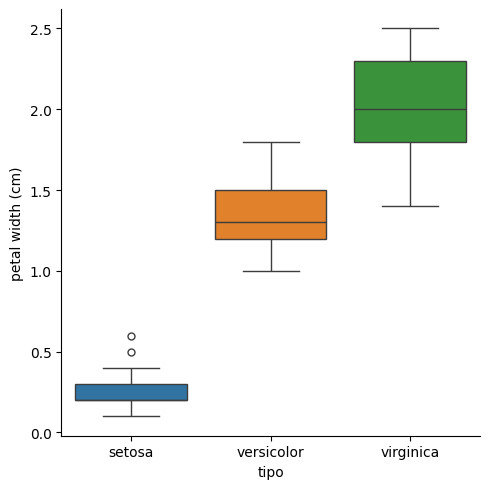

In [57]:
for columna in ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']:
  sns.catplot(data=iris_df, x="tipo", y=columna, kind="box", hue='tipo')

### SVM (Support Vector Machine)

<img src = "https://upload.wikimedia.org/wikipedia/commons/b/b5/Svm_separating_hyperplanes_%28SVG%29.svg?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=original" width="300px">

*Fuente: Wikipedia*

En este algoritmo buscamos optimizar un **hiperplano** que **maximice la distancia** de los **puntos mas cercanos de cada clase**.
\begin{equation} H = \{ x_0, x_2, ..., x_{N-1}\} | \sum_{i=0}^{N-1} a_i x_i = c\end{equation}
Para ilustrar el funcionamiento del algoritmo utilizaremos $N = 2$ dimensiones.

Ademas consideraremos **2 clases** desde el conjunto $X \sim \mathcal{N}(\boldsymbol{\mu}, \sum)$. El problema de optimizacion a resolver consistira en **maximizar el ancho** entre los **puntos mas cercanos al hiperplano** cuya **clase sea distinta**

<img src = "https://upload.wikimedia.org/wikipedia/commons/7/72/SVM_margin.png?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=original" width="300px">

*Fuente: Wikipedia*

In [58]:
from sklearn import svm
from sklearn.utils import shuffle
try:
    from mlxtend.plotting import plot_decision_regions
except:
    !pip install mlxtend

#### Entrenamiento

In [59]:
svm_model = svm.SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

#### Predicción

In [60]:
y_pred = svm_model.predict(X_test)

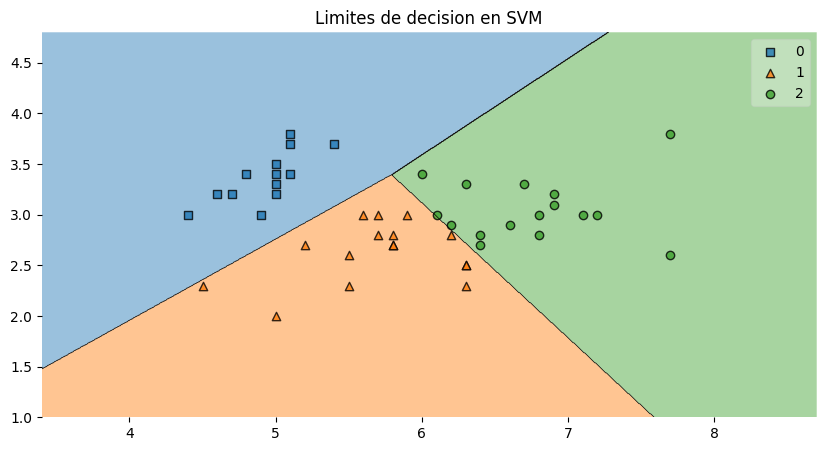

In [61]:
plt.figure(figsize=(10,5))
plot_decision_regions(X=X_test,         # Datos
                      y=y_pred,         # Etiquetas
                      clf=svm_model)
plt.title('Limites de decision en SVM')
plt.show()

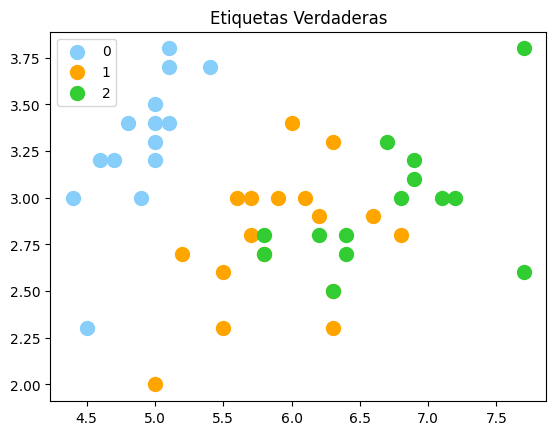

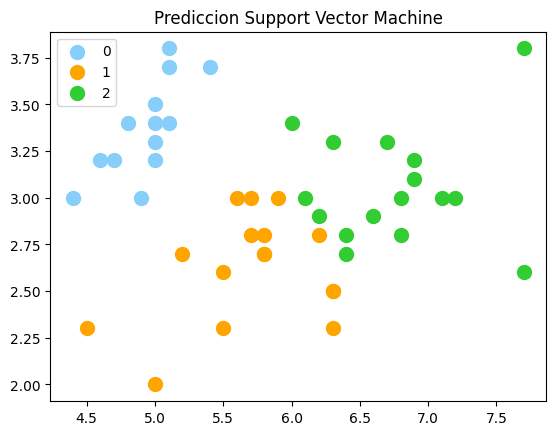

In [62]:
aux = [y_test, y_pred]
for num, title in enumerate(["Etiquetas Verdaderas", "Prediccion Support Vector Machine"]):
  cdict = {0: 'lightskyblue', 1: 'orange', 2: 'limegreen'}
  fig, ax = plt.subplots()
  datos = aux[num]
  x_ = X_test[:,0]
  y_ = X_test[:,1]
  for g in np.unique(datos):
    ix = np.where(datos == g)
    ax.scatter(x_[ix],y_[ix], c = cdict[g], label = g, s = 100)
  plt.title(title)
  plt.legend()
plt.show()


#### Evaluación

In [63]:
# Reporte de clasificación
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.69      0.65      0.67        17
           2       0.62      0.71      0.67        14

    accuracy                           0.76        45
   macro avg       0.77      0.76      0.77        45
weighted avg       0.77      0.76      0.76        45



In [64]:
accuracy_score(y_test,y_pred)

0.7555555555555555

In [65]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, # Etiquetas correctas
                      y_pred)  # Predicción

print(cm)

[[13  1  0]
 [ 0 11  6]
 [ 0  4 10]]


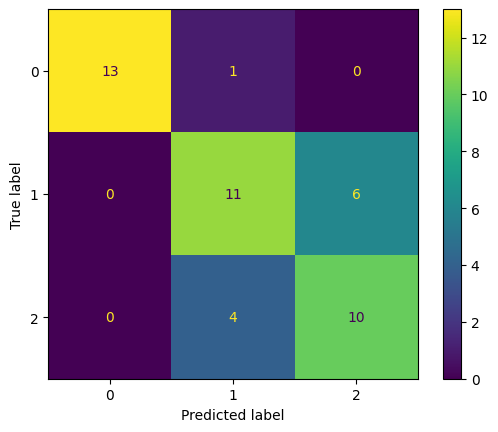

In [66]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

#### Otros kernel

Una de las principales limitaciones de los SVM es que solo funcionan con clases **linealmente separables**.

Para resolver esto podemos hacer una **transformacion** del espacio original (tipicamente de mayor dimensionalidad) donde **asumimos** que los puntos seran linealmente separables.

<img  src="https://scikit-learn.org/stable/_images/sphx_glr_plot_iris_svc_001.png">

*Fuente: Scikit-learn*


Para aplicar esta transformación en python, tenemos **kernel** dentro de los argumentos de la función SVM. Para definir el kernel tenemos las siguientes opciones:
- ‘linear‘
- ‘poly’
- ‘rbf’ (por defecto)
- ‘sigmoid’
- ‘precomputed’

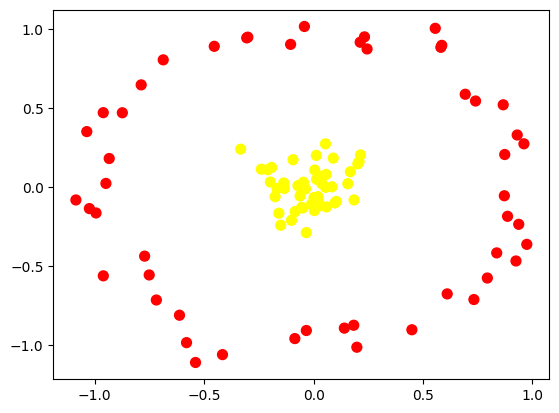

In [67]:
from sklearn.datasets import make_circles
Xnl, ynl = make_circles(100,       # número de muestras.
                        factor=.1, # factor de escalamiento [0,1] entre el círculo interno y externo.
                        noise=.1)  # desviación estandar del ruido gaussiano añadido a los datos.

plt.scatter(Xnl[:, 0], Xnl[:, 1], c=ynl, s=50, cmap='autumn')
plt.show()

In [68]:
model_svm = svm.SVC(kernel='rbf').fit(Xnl, ynl)

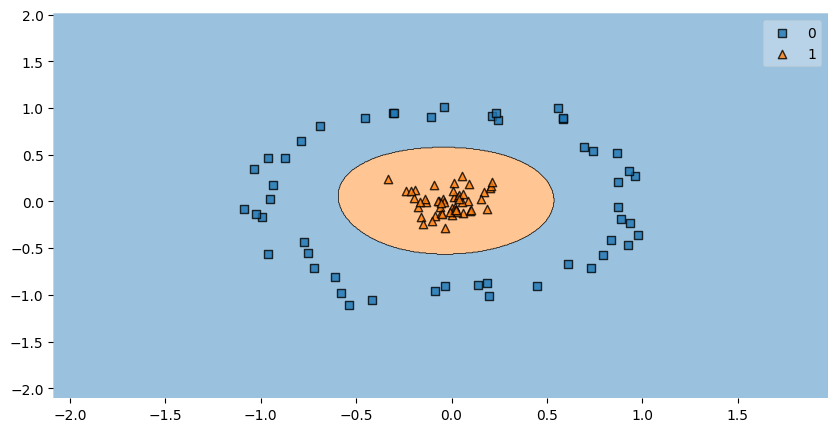

In [69]:
plt.figure(figsize=(10,5))
plot_decision_regions(X=Xnl,
                      y=ynl,
                      clf=model_svm,
                      legend=1)
plt.show()

In [70]:
#### Pausa para ocupar todos los atributos del dataset para los siguientes modelos
X = iris_df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)','petal width (cm)']].values
y = iris_df.species
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=10, shuffle = True)

In [71]:
#Entrenar el svm con el dataset completo
svm_model = svm.SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

### Árbol de decisión

Otra forma de hacer clasficacion discriminativa es utilizar **arboles de decision**.

Este algoritmo consiste de nodos y aristas. Los **nodos** representan las condiciones $t_i$ de separacion de los datos.

En cada separacion crearemos regiones $R_i$ que contiene un subconjunto de los datos.

Cada region $R_i$ aportara informacion en el proceso discriminativo

El proceso se repite recursivamente hasta que se cumpla algun criterio de detencion.

Las **aristas** determinan el camino hacia los nodos hoja (o Regiones finales de separacion), tipicamente represetan la clasficacion final.

#### Entrenamiento

In [72]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

#### Mostrar arbolito

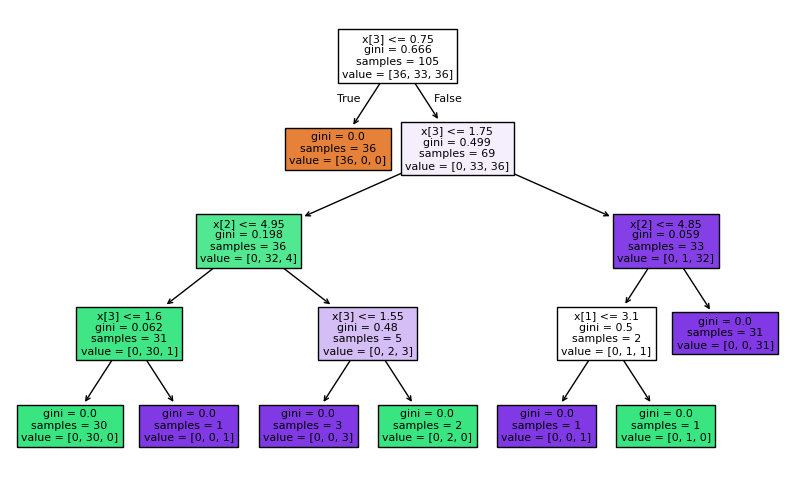

In [73]:
plt.figure(figsize=(10, 6))
tree.plot_tree(dt, filled=True)
plt.show()

#### Predecir

In [74]:
y_pred_dt = dt.predict(X_test)

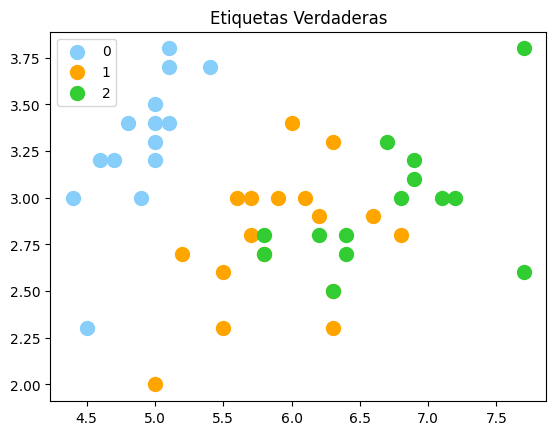

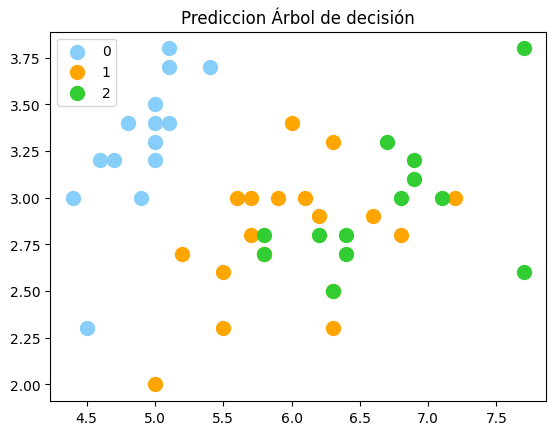

In [75]:
aux = [y_test, y_pred_dt]
for num, title in enumerate(["Etiquetas Verdaderas", "Prediccion Árbol de decisión"]):
  cdict = {0: 'lightskyblue', 1: 'orange', 2: 'limegreen'}
  fig, ax = plt.subplots()
  datos = aux[num]
  x_ = X_test[:,0]
  y_ = X_test[:,1]
  for g in np.unique(datos):
    ix = np.where(datos == g)
    ax.scatter(x_[ix],y_[ix], c = cdict[g], label = g, s = 100)
  plt.title(title)
  plt.legend()
plt.show()

#### Evaluar

In [76]:
# Reporte de clasificación
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      1.00      0.97        17
           2       1.00      0.93      0.96        14

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



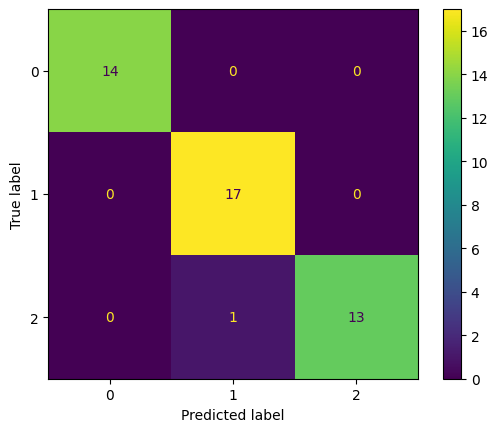

In [77]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)

### Random Forest

* Consiste en utilizar N arboles de decision
* Por cada arbol:
 * Seleccionamos $m$ atributos de manera aleatoria (con reemplazo)
 * Entrenamos usando los $m$ atributos  para dividir cada nodo
* $f(x) = \frac{1}{N}\sum_{i=1}^n f_i(x)$, donde $f_i(x)$ es la etiqueta estimada por el $i$-esimo arbol.

#### Entrenar

In [78]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

#### Predecir

In [79]:
y_pred_rf = rf.predict(X_test)

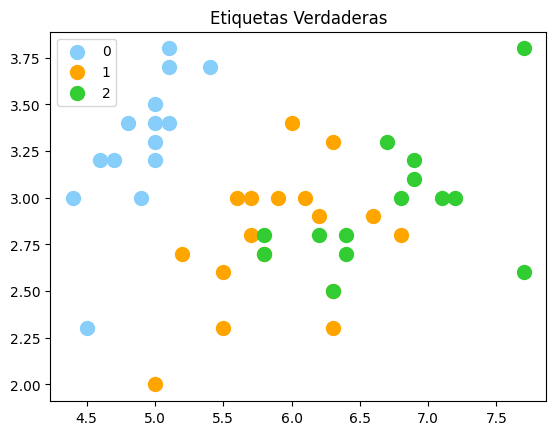

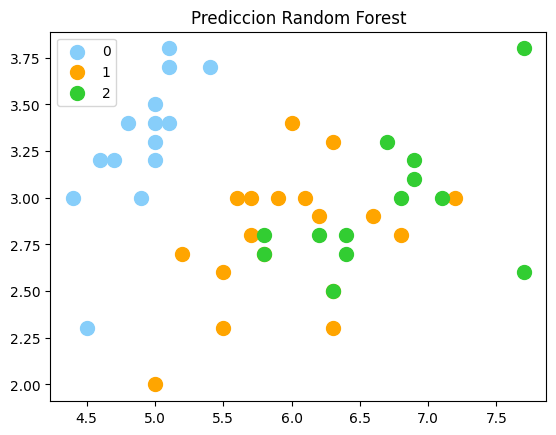

In [80]:
aux = [y_test, y_pred_rf]
for num, title in enumerate(["Etiquetas Verdaderas", "Prediccion Random Forest"]):
  cdict = {0: 'lightskyblue', 1: 'orange', 2: 'limegreen'}
  fig, ax = plt.subplots()
  datos = aux[num]
  x_ = X_test[:,0]
  y_ = X_test[:,1]
  for g in np.unique(datos):
    ix = np.where(datos == g)
    ax.scatter(x_[ix],y_[ix], c = cdict[g], label = g, s = 100)
  plt.title(title)
  plt.legend()
plt.show()

In [81]:
rf.feature_importances_

array([0.12140767, 0.05027691, 0.39784036, 0.43047506])

In [82]:
feature_importances = pd.DataFrame(rf.feature_importances_, index =iris_df.columns[:4],  columns=['importance']).sort_values('importance', ascending=False)
feature_importances

,importance
petal width (cm),0.430475
petal length (cm),0.397840
sepal length (cm),0.121408
sepal width (cm),0.050277


#### Evaluar

In [83]:
# Reporte de clasificación
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      1.00      0.97        17
           2       1.00      0.93      0.96        14

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



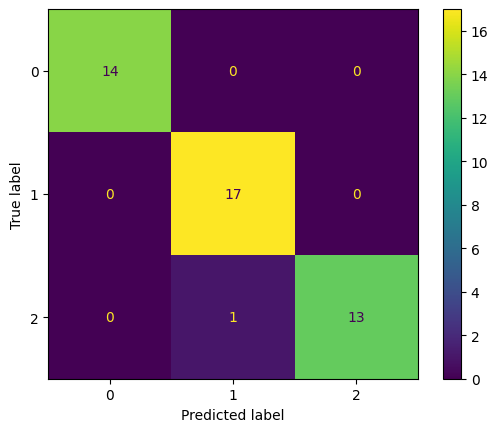

In [84]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

#Resumen

In [85]:
metrics = pd.DataFrame()

acc_list = []
bacc_list = []
pre_list = []
reca_list = []
f1_list = []
for pred in [y_pred, y_pred_dt, y_pred_rf]:
    acc_list.append(accuracy_score(y_test, pred))
    bacc_list.append(balanced_accuracy_score(y_test, pred))
    pre_list.append(precision_score(y_test, pred, average='macro'))
    reca_list.append(recall_score(y_test, pred, average='macro'))
    f1_list.append(f1_score(y_test, pred, average='macro'))

nombres=["SVM", "ARBOL DE DECISION", "RANDOM FOREST"]

metrics['Model'] = nombres
metrics['ACC'] = acc_list
metrics['BACC'] = bacc_list
metrics['Precision'] = pre_list
metrics['Recall'] = reca_list
metrics['F1'] = f1_list

metrics.sort_values('F1', ascending=False)

,Model,ACC,BACC,Precision,Recall,F1
0,SVM,1.000000,1.00000,1.000000,1.00000,1.000000
1,ARBOL DE DECISION,0.977778,0.97619,0.981481,0.97619,0.978131
2,RANDOM FOREST,0.977778,0.97619,0.981481,0.97619,0.978131


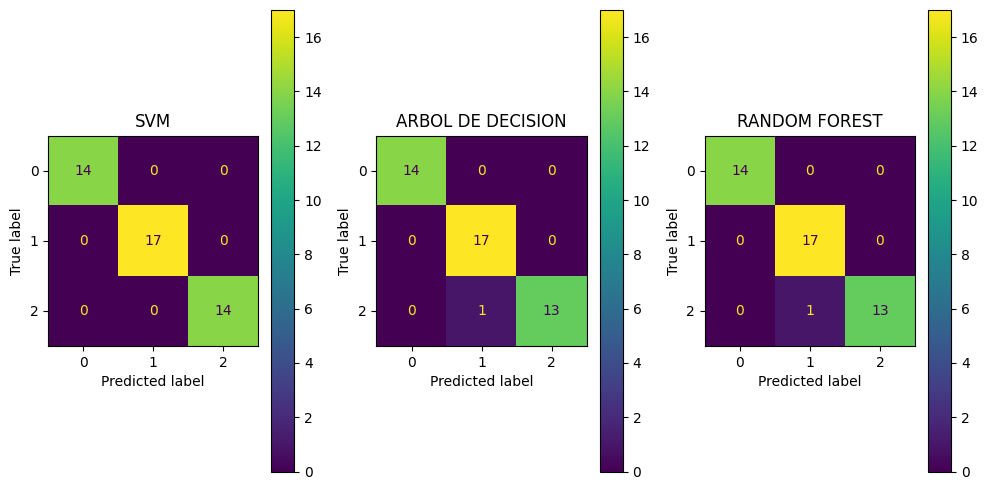

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(10,5), sharex=True, dpi=100)
for i, pred in enumerate([y_pred, y_pred_dt, y_pred_rf]):
  ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=axes[i])
  axes[i].set_title(nombres[i])
fig.tight_layout()
plt.show()

# Ejercicio

Entrenar distintos random forest (con validación cruzada variar el numero de arboles con los valores 25, 50, 75, 100 y 125) y un modelo SVM lineal para el siguiente conjunto de datos para predecir si pasajero sobrevivió o no

Evaluar ambos modelos (mejor random forest y svm) y comparar matrices de confusión.

En este ejercicio usarás el dataset Titanic para predecir la variable **Survived** (0 = No sobrevivió, 1 = Sí sobrevivió).

 **Variables:**
- Sex: sexo del pasajero/a.
- Age: edad del pasajero/a.
- Survived: si el pasajero/a sobrevivió al naufragio, codificada como 0=no y 1=sí
- pClass: clase a la que pertenecía el pasajero/a: 1, 2 o 3.
- Sibsp: 	# of siblings / spouses aboard the Titanic
- Parch: # of parents / children aboard the Titanic
- Fare: precio pagado por el billete.
- embarked: puerto en el que el pasajero/a embarcó en el Titanic. (C = Cherbourg, Q = Queenstown, S = Southampton)

In [87]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic['survived'] = titanic['survived'].apply(lambda x: chr(110 + 11*x))

In [88]:
columnas = ['sex', 'age', 'pclass', 'sibsp', 'parch', 'fare', 'embarked','survived']
titanic = titanic[columnas]
titanic

,sex,age,pclass,sibsp,parch,fare,embarked,survived
0,male,22.0,3,1,0,7.2500,S,n
1,female,38.0,1,1,0,71.2833,C,y
2,female,26.0,3,0,0,7.9250,S,y
3,female,35.0,1,1,0,53.1000,S,y
4,male,35.0,3,0,0,8.0500,S,n
...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,S,n
887,female,19.0,1,0,0,30.0000,S,y
888,female,NaN,3,1,2,23.4500,S,n
889,male,26.0,1,0,0,30.0000,C,y


In [89]:
#### Tu codigo ####

In [90]:
titanic['survived'] = titanic['survived'].map({'y': 1, 'n': 0})

In [91]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       891 non-null    object 
 1   age       714 non-null    float64
 2   pclass    891 non-null    int64  
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
 6   embarked  889 non-null    object 
 7   survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [92]:
titanic.age.fillna(titanic.age.median(), inplace=True)
titanic.dropna(inplace=True)

/tmp/ipykernel_3071/2304971669.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic.age.fillna(titanic.age.median(), inplace=True)


In [93]:
titanic_2 = pd.get_dummies(titanic)

In [94]:
cols = ['sex_female','sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']
titanic_2[cols] = titanic_2[cols].astype(int)

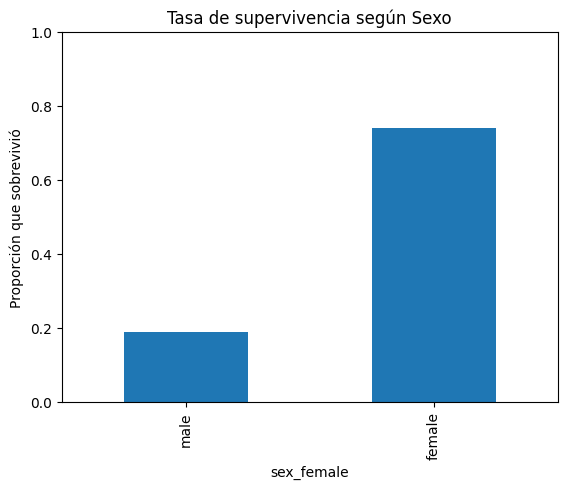

In [95]:
survival_rate_sex = titanic_2.groupby('sex_female')['survived'].mean()
survival_rate_sex.plot.bar()
plt.title('Tasa de supervivencia según Sexo')
plt.ylabel('Proporción que sobrevivió')
plt.xticks([0, 1], ['male', 'female'])
plt.ylim(0,1)
plt.show()

(0.0, 1.0)

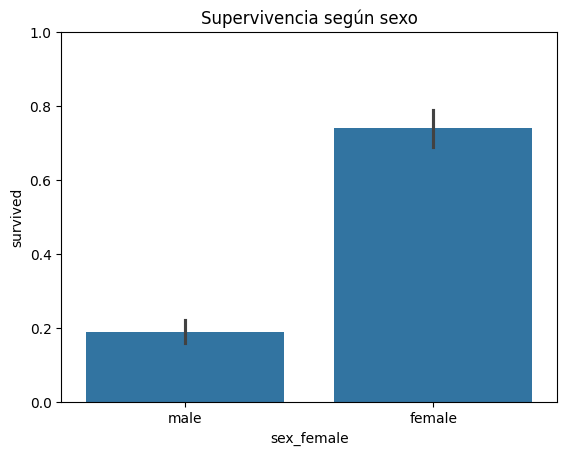

In [96]:
sns.barplot(x='sex_female', y='survived', data=titanic_2)
plt.title('Supervivencia según sexo')
plt.xticks([0, 1], ['male', 'female'])
plt.ylim(0,1)

In [97]:
titanic_2.columns

Index(['age', 'pclass', 'sibsp', 'parch', 'fare', 'survived', 'sex_female',
       'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S'],
      dtype='object')

In [98]:
#Dividir los datos en entrenamiento y test
X = titanic_2[['age', 'pclass', 'sibsp', 'parch', 'fare', 'sex_female', 'embarked_C', 'embarked_Q', 'embarked_S']]
y = titanic_2['survived']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=10, shuffle = True)

In [99]:
#Realizar validación cruzada
from sklearn.model_selection import GridSearchCV
#Creamos nuestro modelo
modelo = RandomForestClassifier()

numero_folds = 4

parametros = {
    "n_estimators" : [25, 50, 75,100,125]
}

cv_model = GridSearchCV(modelo,
                        parametros,
                        cv=numero_folds, #Aqui se indica el numero de folds
                        scoring='accuracy',
                        verbose=3) #Le pasamos el modelo, los parametros, numero de folds y la métrica


cv_model.fit(X_train, y_train)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
[CV 1/4] END ...................n_estimators=25;, score=0.840 total time=   0.1s
[CV 2/4] END ...................n_estimators=25;, score=0.731 total time=   0.1s
[CV 3/4] END ...................n_estimators=25;, score=0.755 total time=   0.1s
[CV 4/4] END ...................n_estimators=25;, score=0.832 total time=   0.1s
[CV 1/4] END ...................n_estimators=50;, score=0.846 total time=   0.2s
[CV 2/4] END ...................n_estimators=50;, score=0.750 total time=   0.2s
[CV 3/4] END ...................n_estimators=50;, score=0.806 total time=   0.2s
[CV 4/4] END ...................n_estimators=50;, score=0.826 total time=   0.2s
[CV 1/4] END ...................n_estimators=75;, score=0.846 total time=   0.2s
[CV 2/4] END ...................n_estimators=75;, score=0.744 total time=   0.2s
[CV 3/4] END ...................n_estimators=75;, score=0.794 total time=   0.3s
[CV 4/4] END ...................n_estimators=75;,

GridSearchCV(cv=4, estimator=RandomForestClassifier(),
             param_grid={'n_estimators': [25, 50, 75, 100, 125]},
             scoring='accuracy', verbose=3)

In [100]:
cv_model.best_params_

{'n_estimators': 50}

In [101]:
#Evaluar mejor modelo
mejor_rf = cv_model.best_estimator_
prediccion_rf = mejor_rf.predict(X_test)

print(classification_report(y_test,prediccion_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       169
           1       0.78      0.70      0.74        98

    accuracy                           0.82       267
   macro avg       0.81      0.80      0.80       267
weighted avg       0.82      0.82      0.82       267



In [102]:
#Entrenar y evaluar svm
svm_ = svm.SVC(kernel='linear')
svm_.fit(X_train, y_train)
prediccion_svm = svm_.predict(X_test)
print(classification_report(y_test,prediccion_svm))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       169
           1       0.76      0.64      0.70        98

    accuracy                           0.79       267
   macro avg       0.78      0.76      0.77       267
weighted avg       0.79      0.79      0.79       267



Text(0.5, 1.0, 'SVM')

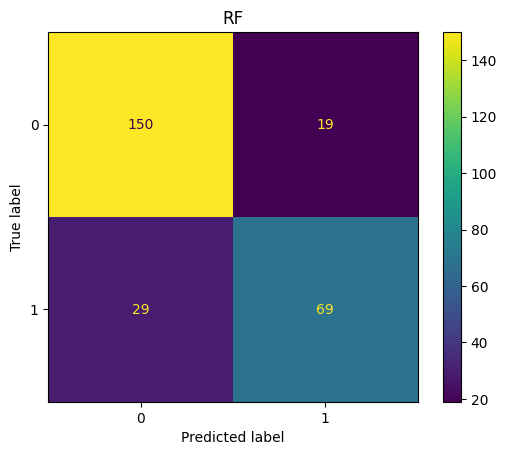

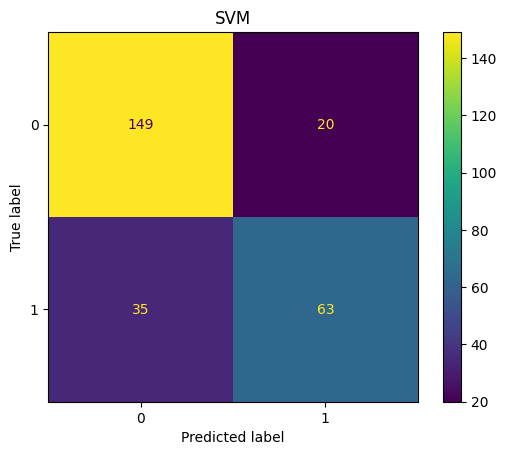

In [103]:
ConfusionMatrixDisplay.from_predictions(y_test, prediccion_rf)
plt.title("RF")
ConfusionMatrixDisplay.from_predictions(y_test, prediccion_svm)
plt.title("SVM")